## 03 PyTorch Computer vision Exercise Solutions

The following is one of the possible set (there can be many more way to do the problems) of solutions for the 0.3 PyTorch Computer Vision template



In [ ]:
import torch

# Exercies require PyTorch > 1.10.0
print(torch.__version__)
# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.9.0+cu126


'cuda'

### what are the 3 areas of industry where Computer vision is currently used

1 * Self driving cars like Wyamo
2 * Health care such as in X-rays
3 * Security , computer vision is used for detecting whether someone invading the home or not

## 3 . What is overfitting and how can we prevent it

1**Regularization techniques** - Can use Dropout in NNs , it involve randomly removing neurons in different layers so that the remaining neurons hopefully learn more robust weights/patterns

2 Use different model - maybe the model you're using for a specific problem is too complicated, as in, it's learning the data too well because it has so many layers.
You can remove some layers to simplify the model. Or pick a new model ...One that suit well to the problem

3 **Reduce noise in data/cleanup dataset/introduce data augmentaion**
_ If the model is learning the data too well it might be just memorizing the data, including the noise, One option is to remove noise/claen up the data or you can introduce artificial noise through the data augmentation to artificially increase the diversity of the training dataset.


## 5. Load `torchvision.datasets.MNIST()` train and test datasets.


In [ ]:
import torchvision
from torchvision import datasets

from torchvision import transforms


In [ ]:
# Get te MNIST train dataset
train_data = datasets.MNIST(root=".",
                           train=True,
                           download=True,
                           transform=transforms.ToTensor())

# Get the Mnist test datasets
test_data = datasets.MNIST(root=".",
                          train=False,
                          download=True,
                          transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [ ]:
train_data, test_data


(Dataset MNIST
     Number of datapoints: 60000
     Root location: .
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: .
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# Data isin tuple form (image, label)

img = train_data[0][0]
label = train_data[0][1]
print(f"Image:\n", {img})
print(f"Label:\n", {label})

Image:
 {tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [ ]:
# Check out the shape of the data
print(f"Image shape: {img.shape} -> [color_channels, height, width] (CHW)")
print(f"Label {label} -> no shape , due to being integer")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width] (CHW)
Label 5 -> no shape , due to being integer


Note: There are two main agreed upon ways for representing images in machine learning

1. Color channels first : [color_channels, height, width] (CHW) ->Pytorch default (as of now)
2. Color channels last: [height, width, color_channels] [H, W, C] -> matplotlib / TensorFlow default

In [ ]:
# get the class names from the dataset
class_names = train_data.classes

class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## Visualize at least the 5 different samples of the MNIST training dataset


torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])


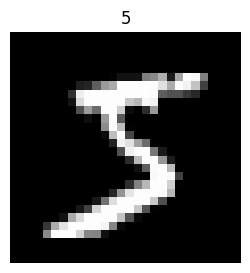

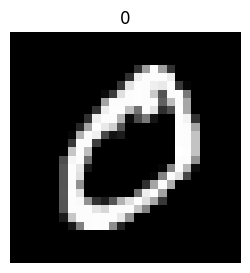

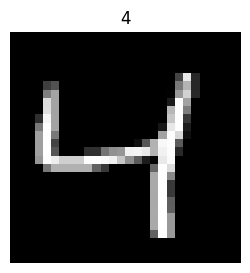

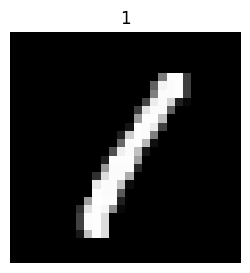

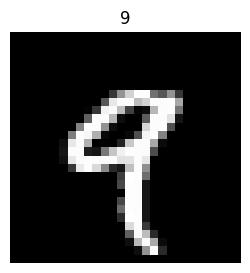

In [ ]:
import matplotlib.pyplot as plt
for i in range(5):
  img = train_data[i][0]
  print(img.shape)
  img_squeeze = img.squeeze()
  print(img_squeeze.shape)
  label = train_data[i][1]
  plt.figure(figsize=(3, 3))
  plt.imshow(img_squeeze, cmap='gray')
  plt.title(label)
  plt.axis(False)


## Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader` set the batch_size=32


In [ ]:
# create train dataloader

from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False)

In [ ]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ea264516ae0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ea38cab9010>)

In [ ]:
for sample in next(iter(train_dataloader)):
  print(sample.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [ ]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

## 8. Create `model_2` used inthe notebook 03 (the same from the CNN Explainer website, also known as TinyVGG) capable of fitting on the MNIST dataset.

In [ ]:
from torch import nn
class MNIST_model(torch.nn.Module):
  """Model capable of predicting on MNIST dataset.
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*7*7,
                out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    print(f"Output shape of conv block 1: {x.shape}")
    x = self.conv_block_2(x)
    print(f"Output shape of conv block 2: {x.shape}")
    x = self.classifier(x)
    print(f"Output shape of classifier: {x.shape}")
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device




'cuda'

In [ ]:
model = MNIST_model(input_shape=1,
                    hidden_units =10,
                    output_shape=10).to(device)
model

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
# Check out the model state to find out what paterns  our model wants to learn
model.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[-0.2073,  0.2245, -0.0084],
                        [-0.0481,  0.1407,  0.2143],
                        [-0.1618, -0.0518, -0.2614]]],
              
              
                      [[[ 0.3196,  0.1591, -0.0813],
                        [-0.1389, -0.3105, -0.0653],
                        [-0.2239, -0.0481,  0.1418]]],
              
              
                      [[[-0.2085,  0.0046, -0.0124],
                        [-0.0973, -0.1238,  0.0105],
                        [-0.1104,  0.0597,  0.2801]]],
              
              
                      [[[ 0.0709,  0.2304, -0.1744],
                        [-0.2514, -0.1732, -0.1617],
                        [-0.0450,  0.3262, -0.2135]]],
              
              
                      [[[ 0.1504,  0.0909,  0.1858],
                        [ 0.1802, -0.0510, -0.3108],
                        [-0.0226,  0.2013,  0.1841]]],
              
              
      

In [ ]:
# Try a dummy forward pass to see what shapes our data is
dummy_x = torch.rand(size=(1, 28, 28)).unsqueeze(dim=0).to(device)
model(dummy_x)

Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])


tensor([[-0.0621,  0.0203,  0.0297,  0.0046,  0.0461,  0.0641, -0.0444, -0.0194,
          0.0738,  0.0733]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
dummy_x_2  = torch.rand(size=([1, 10, 7, 7]))
dummy_x_2.shape

torch.Size([1, 10, 7, 7])

In [ ]:
flatten_layer = nn.Flatten()
flatten_layer(dummy_x_2).shape


torch.Size([1, 490])

In [ ]:
%%time
from tqdm.auto import tqdm

# Train on CPU
model_cpu = MNIST_model(input_shape=1,
                        hidden_units=10,
                        output_shape=10).to("cpu")

# Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_cpu.parameters(), lr=0.1)

### Training loop
epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss = 0
  for batch, (X, y) in enumerate(train_dataloader):
    model_cpu.train()

    # Put data on CPU
    X, y = X.to("cpu"), y.to("cpu")

    # Forward pass
    y_pred = model_cpu(X)

    # Loss calculation
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss backward
    loss.backward()

    # Step the optimizer
    optimizer.step()

  # Adjust train loss for number of batches
  train_loss /= len(train_dataloader)

  ### Testing loop
  test_loss_total = 0

  # Put model in eval mode
  model_cpu.eval()

  # Turn on inference mode
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_dataloader):
      # Make sure test data on CPU
      X_test, y_test = X_test.to("cpu"), y_test.to("cpu")
      test_pred = model_cpu(X_test)
      test_loss = loss_fn(test_pred, y_test)

      test_loss_total += test_loss

    test_loss_total /= len(test_dataloader)

  # Print out what's happening
  print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss_total:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of co

In [25]:
%%time
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Train on GPU
model_gpu = MNIST_model(input_shape=1,
                        hidden_units=10,
                        output_shape=10).to(device)

# Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_gpu.parameters(), lr=0.1)

# Training loop
epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss = 0
  model_gpu.train()
  for batch, (X, y) in enumerate(train_dataloader):
    # Put data on target device
    X, y = X.to(device), y.to(device)

    # Forward pass
    y_pred = model_gpu(X)

    # Loss calculation
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss backward
    loss.backward()

    # Step the optimizer
    optimizer.step()

  # Adjust train loss to number of batches
  train_loss /= len(train_dataloader)

  ### Testing loop
  test_loss_total = 0
  # Put model in eval mode and turn on inference mode
  model_gpu.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_dataloader):
      # Make sure test data on target device
      X_test, y_test = X_test.to(device), y_test.to(device)

      test_pred = model_gpu(X_test)
      test_loss = loss_fn(test_pred, y_test)

      test_loss_total += test_loss

    # Adjust test loss total for number of batches
    test_loss_total /= len(test_dataloader)

  # Print out what's happening
  print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss_total:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of co

## 10. Make predictions using the trained model and visualize atleast 5 of them comparing the prediction to the target label


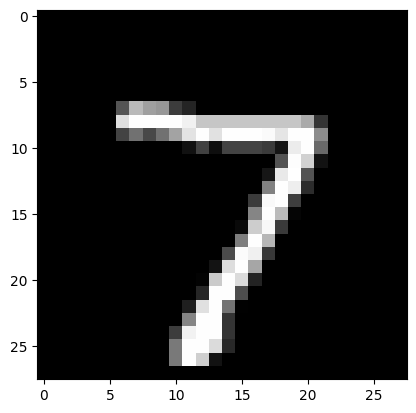

In [27]:
# Make predcition with the trained model
plt.imshow(test_data[0][0].squeeze(), cmap="gray")

In [28]:
# logits -> Prediction probabilities -> Prediction labels
model_pred_logits = model_gpu(test_data[0][0].unsqueeze(dim=0).to(device))
model_pred_probs = torch.softmax(model_pred_logits, dim=1)
model_pred_label = torch.argmax(model_pred_probs, dim=1)
model_pred_label

Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])


tensor([7], device='cuda:0')

Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])
Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])
Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])
Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])
Output shape of conv block 1: torch.Size([1, 10, 14, 14])
Output shape of conv block 2: torch.Size([1, 10, 7, 7])
Output shape of classifier: torch.Size([1, 10])


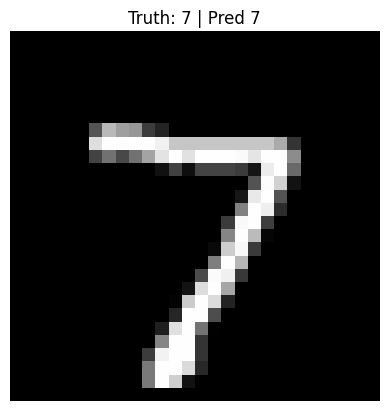

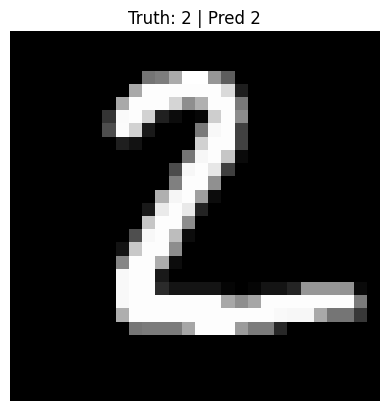

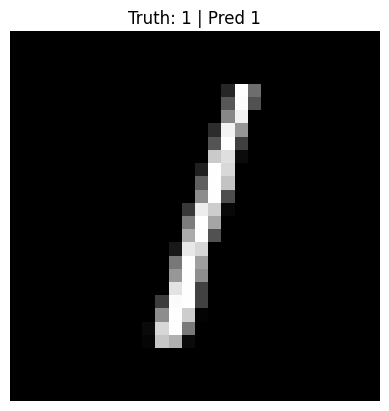

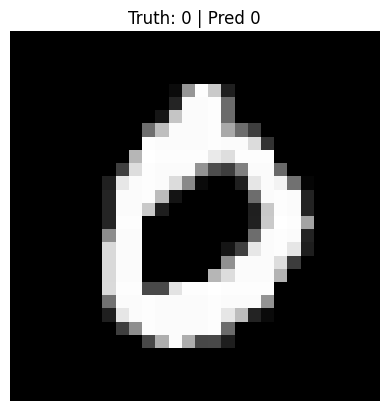

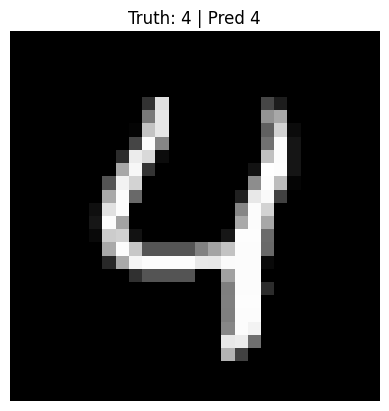

In [29]:
num_to_plot = 5
for i in range(num_to_plot):
  # Get the image and labels from the test data
  img = test_data[i][0]
  label = test_data[i][1]

  # Make prediction on image
  model_pred_logits = model_gpu(img.unsqueeze(dim=0).to(device))
  model_pred_probs = torch.softmax(model_pred_logits, dim=1)
  model_pred_label = torch.argmax(model_pred_probs, dim=1)

  # Plot the image and prediction
  plt.figure()
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(f"Truth: {label} | Pred {model_pred_label.cpu().item()}")
  plt.axis(False)


#11 Plot a confusion matrix comparing the model's predictions to the truth labels.


In [30]:
# see if torchmetrics exists , if not install it
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version : {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 ot higher"
except:
  !pip install -q torchmetrics -U mlxtend  # we need to restart as we using colab
  import torchmetrics , mlxtend
  print(f"mlxtend version : {mlxtend.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 143.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [32]:
# import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19

0.24.0


In [36]:
# Make predictions across all test data
from tqdm.auto import tqdm
model_gpu.eval()
y_preds = []
with torch.inference_mode():
  for batch, (X, y) in tqdm(enumerate(test_dataloader)):
    # Make sure data on right device
    X, y = X.to(device), y.to(device)
    # Forward pass
    y_pred_logits = model_gpu(X)
    # Logits -> Pred probs -> Pred label
    y_pred_labels = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)
    # Append the labels to the preds list
    y_preds.append(y_pred_labels)
  y_preds=torch.cat(y_preds).cpu()
len(y_preds)

0it [00:00, ?it/s]

Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output sha

10000

In [37]:
test_data.targets[:10], y_preds[:10]


(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]))

In [39]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds,
                         target=test_data.targets)

# Plot the confusion matrix
fix, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [41]:
import torch

num_classes = len(class_names)
confmat = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for t, p in zip(test_data.targets, y_preds):
    confmat[t, p] += 1

print(confmat)


tensor([[ 978,    0,    1,    0,    0,    0,    0,    1,    0,    0],
        [   2, 1126,    2,    1,    0,    2,    1,    0,    1,    0],
        [   1,    5, 1018,    1,    0,    0,    0,    3,    4,    0],
        [   1,    1,    1,  991,    0,    9,    0,    2,    4,    1],
        [   2,    0,    1,    0,  971,    0,    1,    1,    4,    2],
        [   0,    0,    0,    3,    0,  886,    2,    1,    0,    0],
        [   5,    2,    0,    0,    1,    9,  938,    0,    3,    0],
        [   0,    5,    4,    0,    0,    1,    0, 1016,    2,    0],
        [   3,    0,    3,    0,    1,    4,    0,    0,  963,    0],
        [   2,    4,    0,    1,   13,    5,    0,    5,    6,  973]])


## 12 Create a random tensor of shape [1, 3, 64, 64] and pass it through nn.Conv2d() layer with various hyperarameter setting (these can be any setting you choose) what you notice if the `kernel_size` parameter goes up and down?

In [44]:
random_tensor = torch.rand([1, 3, 64, 64])
random_tensor.shape

torch.Size([1, 3, 64, 64])

In [45]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=64,
                       kernel_size=3,
                       stride=2,
                       padding=1)

print(f"random tensor shape: {random_tensor.shape}")
random_tensor_through_conv_layer = conv_layer(random_tensor)
print(f"Random tensor through conv layer shape: {random_tensor_through_conv_layer.shape}")

random tensor shape: torch.Size([1, 3, 64, 64])
Random tensor through conv layer shape: torch.Size([1, 64, 32, 32])


## 13 Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test `torchvision.dataset.FashionMNIST` dataset

* Then plot some predictions where the model was wrong alongside what the label of the image should've been
* After visualizing these prediction do you think it's more of a modellng error or a data error?
* As in , could the model do better or are the labels of these close to each other (eg: "Shirt" label is too close to "T-shirt/top")?

In [50]:
from torchvision import  datasets
from torchvision import transforms

fashion_mnist_train = datasets.FashionMNIST(root=".",
                                             download=True,
                                             train=True,
                                             transform=transforms.ToTensor())

fashion_mnist_test = datasets.FashionMNIST(root=".",
                                           download=True,
                                           train=False,
                                           transform=transforms.ToTensor())


len(fashion_mnist_train), len(fashion_mnist_test)

(60000, 10000)

In [51]:
# get the class names of the FashionMNIST dataset
fashion_minist_class_names = fashion_minist_train.classes
fashion_minist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [52]:
# Turn  FashionMNIST dataset into dataloaders
from torch.utils.data import DataLoader

fashion_mnist_train_dataloader = DataLoader(fashion_mnist_train,
                                            batch_size=32,
                                            shuffle=True)

fashion_mnist_test_dataloader = DataLoader(fashion_mnist_test,
                                          batch_size=32,
                                          shuffle=False)

len(fashion_mnist_train_dataloader),len(fashion_mnist_test_dataloader)

(1875, 313)

In [53]:
# Model_2 is the same architecture as MNIST_model
model_2 = MNIST_model(input_shape=1,
                      hidden_units=10,
                      output_shape=10).to(device)

model_2

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [54]:
# set up loss and optimizer
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [60]:
def acc_fn(y_pred, y_true):
    # y_pred: logits (batch_size, num_classes)
    y_pred_class = torch.argmax(y_pred, dim=1)
    correct = (y_pred_class == y_true).sum().item()
    return correct / len(y_true)


In [61]:
# Setup metrics
from tqdm.auto import tqdm


# Setup training/testing loop
epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss, test_loss_total = 0, 0
  train_acc, test_acc = 0, 0

  ### Training
  model_2.train()
  for batch, (X_train, y_train) in enumerate(fashion_mnist_train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device)

    # Forward pass and loss
    y_pred = model_2(X_train)
    loss = loss_fn(y_pred, y_train)
    train_loss += loss
    train_acc += acc_fn(y_pred, y_train)

    # Backprop and gradient descent
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # Adjust the loss/acc (find the loss/acc per epoch)
  train_loss /= len(fashion_mnist_train_dataloader)
  train_acc /= len(fashion_mnist_train_dataloader)

  ### Testing
  model_2.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(fashion_mnist_test_dataloader):
      X_test, y_test = X_test.to(device), y_test.to(device)

      # Forward pass and loss
      y_pred_test = model_2(X_test)
      test_loss = loss_fn(y_pred_test, y_test)
      test_loss_total += test_loss

      test_acc += acc_fn(y_pred_test, y_test)

    # Adjust the loss/acc (find the loss/acc per epoch)
    test_loss /= len(fashion_mnist_test_dataloader)
    test_acc /= len(fashion_mnist_test_dataloader)

  # Print out what's happening
  print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Train acc: {train_acc:.2f} | Test loss: {test_loss_total:.3f} | Test acc: {test_acc:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of 

In [63]:
test_preds = []
model_2.eval()
with torch.inference_mode():
  for X_test, y_test in tqdm(fashion_mnist_test_dataloader):
    y_logits = model_2(X_test.to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_pred_labels = torch.argmax(y_pred_probs, dim=1)
    test_preds.append(y_pred_labels)
test_preds = torch.cat(test_preds).cpu()
test_preds[:10], len(test_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output shape of conv block 1: torch.Size([32, 10, 14, 14])
Output shape of conv block 2: torch.Size([32, 10, 7, 7])
Output shape of classifier: torch.Size([32, 10])
Output sha

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000)

In [64]:
# Get wrong prediction indexes
import numpy as np
wrong_pred_indexes = np.where(test_preds != fashion_mnist_test.targets)[0]
len(wrong_pred_indexes)

1351

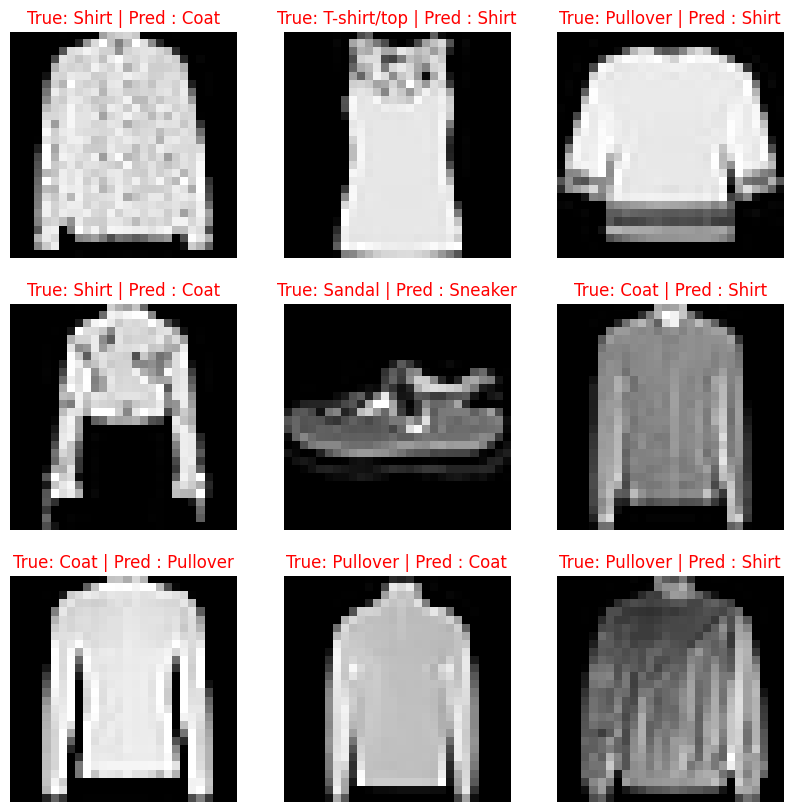

In [67]:
import random
random_selection = random.sample(list(wrong_pred_indexes), k=9)

plt.figure(figsize=(10, 10))
for i,idx in enumerate(random_selection):
  # get the true and pred labels
  true_label = fashion_minist_class_names[fashion_mnist_test[idx][1]]
  pred_label = fashion_minist_class_names[test_preds[idx]]

  # plot the wrong preduction with its original lael
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_mnist_test[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred : {pred_label}",c="r")
  plt.axis(False)

From the look of some of these predictions, the model is getting about as confused as I would...

For example it predicts "Sneaker" instead of "Sandal" when it could have easily been a "Sneaker".

The same goes for the confusion between the classes of "T-shirt/top" and "Shirt", many of the examples here look similar.